In [14]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

(930, 1200, 3)


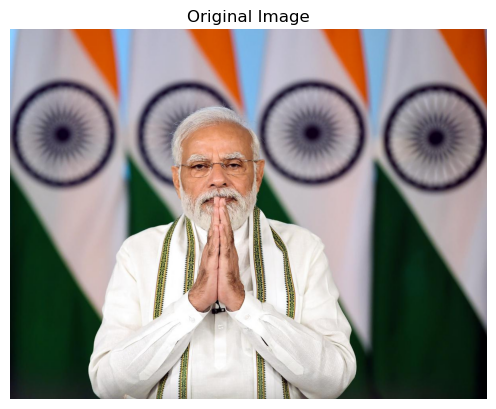

In [2]:
img = cv2.imread("modi-g-3.jpg")
#img = Image.open("modi-g-3.jpg")
image = np.array(img)
print(image.shape)
height, width, channels = image.shape

#Converting original image from BGR to RGB to make it matplotlib readable
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

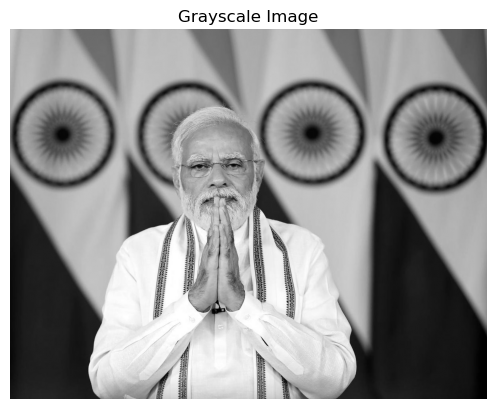

In [3]:
gray = np.zeros((height, width), dtype=np.uint8)
for i in range(height):
    for j in range(width):
        B = image[i][j][0]
        G = image[i][j][1]
        R = image[i][j][2]

        gray_value = 0.299*R + 0.587*G + 0.114*B
        #gray_value = (B+G+R)/3
        gray[i][j] = int(gray_value)
#cv2.imwrite("gray.jpg", gray)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

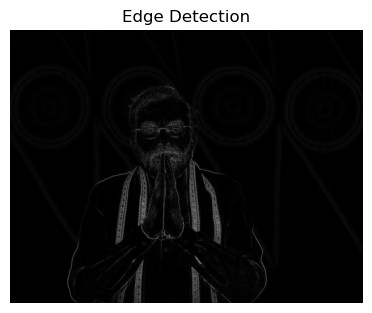

In [13]:
def simple_edge_detection(image):
    if len(image.shape) == 3:
        image = np.mean(image, axis=2)
    

    grad_x = np.abs(np.diff(image, axis=1))
    grad_y = np.abs(np.diff(image, axis=0))
    grad_x = np.pad(grad_x, ((0, 0), (0, 1)), mode='edge')
    grad_y = np.pad(grad_y, ((0, 1), (0, 0)), mode='edge')
    
    edges = np.sqrt(grad_x**2 + grad_y**2)
    edges = (edges / edges.max() * 255).astype(np.uint8)
    
    return edges

image = cv2.imread("modi-g-3.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


edges = simple_edge_detection(image)


plt.figure(figsize=(10,5))

# plt.subplot(1,2,1)
# plt.imshow(image_rgb)
# plt.title("Original")
# plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')

plt.show()

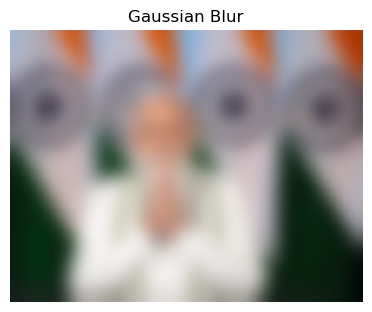

In [12]:
#Gaussian Blur



n = 51  
sigma = 8

ax_range = np.arange(-(n//2), n//2 + 1)
X, Y = np.meshgrid(ax_range, ax_range)

gauss_kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
gauss_kernel = gauss_kernel / np.sum(gauss_kernel)
plt.show()

img = cv2.imread("modi-g-3.jpg")

scale = 0.25
img = cv2.resize(img, (0,0), fx=scale, fy=scale)

imgFilter = cv2.GaussianBlur(img, (n, n), sigma)

blur_rgb = cv2.cvtColor(imgFilter, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
plt.imshow(blur_rgb)
plt.title("Gaussian Blur")
plt.axis('off')

plt.show()




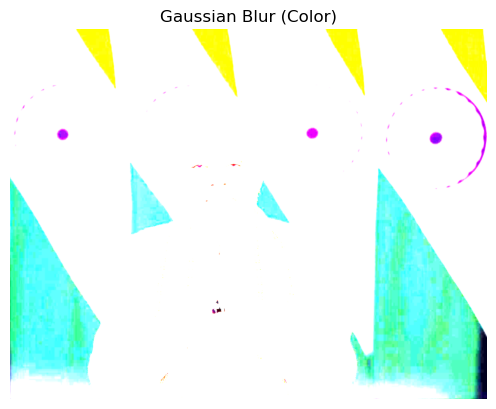

In [5]:
# k = 5
# mid = k//2
# # kernel = np.array([[1, 2, 1],
# #                    [2, 4, 2],
# #                    [1, 2, 1]])
# # height, width, channels = image.shape
# # img_h, img_w = height, width

# # padded = np.pad(image, ((1,1), (1,1), (0,0)), mode='constant')

# # blur = np.zeros((height, width, channels), dtype=np.float32)

# # kernel_size = kernel.shape[0]

# # for i in range(kernel_size):
# #     for j in range(kernel_size):
# #         window = padded[i:i + img_h, j:j + img_w]
# #         blur += kernel[i, j] * window

# # # Convert back to uint8
# # blur = np.clip(blur, 0, 255).astype(np.uint8)

# # # Display result
# # blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)
# # plt.imshow(blur_rgb)
# # plt.title("Gaussian Blur (Color)")
# # plt.axis('off')
# # plt.show()